# Thermosolutal convection of a Darcy fluid

## Create and run the simulation

In [1]:
from functools import partial
import numpy as np
from lucifex.fdm import AB2, CN
from lucifex.sim import run, xdmf_to_npz
from lucifex.plt import (
    plot_colormap_multifigure, plot_line, create_animation, save_figure, 
    display_animation, get_ipynb_file_name, set_ipynb_variable,
)
from crocodil.dns import dns_darcy_thermosolutal

STORE = 1
WRITE = None
DIR_ROOT = f'./figures/{get_ipynb_file_name()}'
DIR_PARAMS = ('Ra', 'Le', 'gamma', 'Nx', 'Ny')

simulation = dns_darcy_thermosolutal(
    store_delta=STORE, 
    write_delta=WRITE, 
    dir_root=DIR_ROOT, 
    dir_params=DIR_PARAMS,
    dir_datetime=False,
)(
    Nx=64,
    Ny=64,
    cell='quadrilateral', 
    scaling='advective',
    Ra=250.0,
    Le=2.0,
    gamma=1.0,
    D_adv_solutal=AB2, 
    D_diff_solutal=CN,
    D_adv_thermal=AB2, 
    D_diff_thermal=CN,
    diagnostic=True,
)

n_stop = set_ipynb_variable('N_STOP', 500)
dt_init = 1e-3
n_init = 10
run(simulation, n_stop=n_stop, dt_init=dt_init, n_init=n_init, show_progress=True)
if WRITE: xdmf_to_npz(simulation, delete_xdmf=False)

c, theta, u, psi = simulation['c', 'theta', 'u', 'psi']
save_fig = partial(save_figure, dir_path=simulation.dir_path, prefix=False)

Environment variable `N_STOP=400`


  0%|          | 0/400 [00:00<?, ?it/s]

## Visualization

In [2]:
title_doublet = lambda time_doublet, tex_doublet: (
    tuple(f'${n}(t={t:.6f})$' for t, n in zip(time_doublet, tex_doublet))
)
series_doublet = (c, theta)
tex_doublet = ('c', '\\theta')

time_slice = slice(0, None, 2)
time_doublet_series = [ti for ti in zip(*[s.time_series[time_slice] for s in series_doublet])]

anim = create_animation(
    plot_colormap_multifigure(n_cols=2, cbars=False),
    cmap=('hot', 'plasma'),
)(
    [ui for ui in zip(*[s.series[time_slice] for s in series_doublet])],
    title=[title_doublet(i, tex_doublet) for i in time_doublet_series],
)
anim_path = save_fig('c(t)_theta(t)', return_path=True)(anim)

display_animation(anim_path)

## Diagnostics

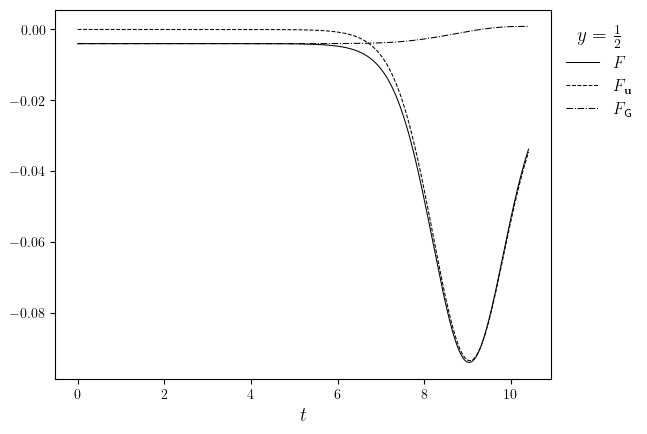

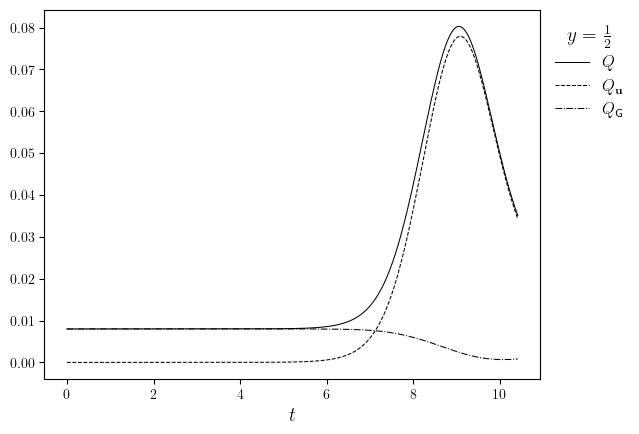

In [3]:
f = simulation['f']
fZeta0, fZetaPlus, fZetaMinus = f.split()
fig, ax = plot_line(
    [(fZeta0.time_series, [np.sum(i) for i in fZeta0.value_series]), (fZeta0.time_series, fZeta0.value_series)],
    cyc='black',
    x_label='$t$',
    legend_labels=['$F$', '$F_{\\mathbf{u}}$', '$F_{\mathsf{G}}$'],
    legend_title='$y=\\frac{1}{2}$',
)
save_fig('f(t)')(fig)

q = simulation['q']
q, qPlus, qMinus = q.split()
fig, ax = plot_line(
    [(q.time_series, [np.sum(i) for i in q.value_series]), (q.time_series, q.value_series)],
    cyc='black',
    x_label='$t$',
    legend_labels=['$Q$', '$Q_{\\mathbf{u}}$', '$Q_{\mathsf{G}}$'],
    legend_title='$y=\\frac{1}{2}$',
)
save_fig('q(t)')(fig)